# Imports

In [1]:
%reload_ext autoreload
%autoreload 2
import seaborn as sns
import anndata as ad 
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import numpy as np
from scipy.sparse import csr_matrix
import sys
from tqdm import tqdm

sys.path.insert(0, '../')
from task_grn_inference.src.utils.util import colors_blind
from task_grn_inference.src.exp_analysis.helper import Exp_analysis, plot_interactions, create_interaction_info, create_interaction_df, jaccard_similarity_net, cosine_similarity_net, calculate_feature_distance, plot_cumulative_density
from task_grn_inference.src.utils.util import basic_qc, read_gmt

from src.helper_plots import exp_plots


# Process raw dataset

In [2]:
# python src/helper_dataset.py

In [3]:
# exp_plots(obs.groupby('age_group'), cell_type=True)

# Explanatory analysis

In [22]:
from src.helper import  major_cell_types


In [23]:
if True:
    adata = ad.read_h5ad('input/data1.h5ad')
    adata = adata[adata.obs['cell_type'].isin(major_cell_types), :]
    sc.pp.normalize_total(adata)
    sc.pp.log1p(adata)
    sc.pp.highly_variable_genes(adata, n_top_genes=2000)

    sc.pp.pca(adata, use_highly_variable=True)  
    sc.pp.neighbors(adata, n_neighbors=15)  
    sc.tl.umap(adata)  
    adata.write('input/data1_umap.h5ad')
else:
    adata = ad.read_h5ad('input/dataset_1_umap.h5ad')

/home/jnourisa/miniconda3/envs/py10/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:207: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/home/jnourisa/miniconda3/envs/py10/lib/python3.10/site-packages/scanpy/preprocessing/_pca.py:385: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)


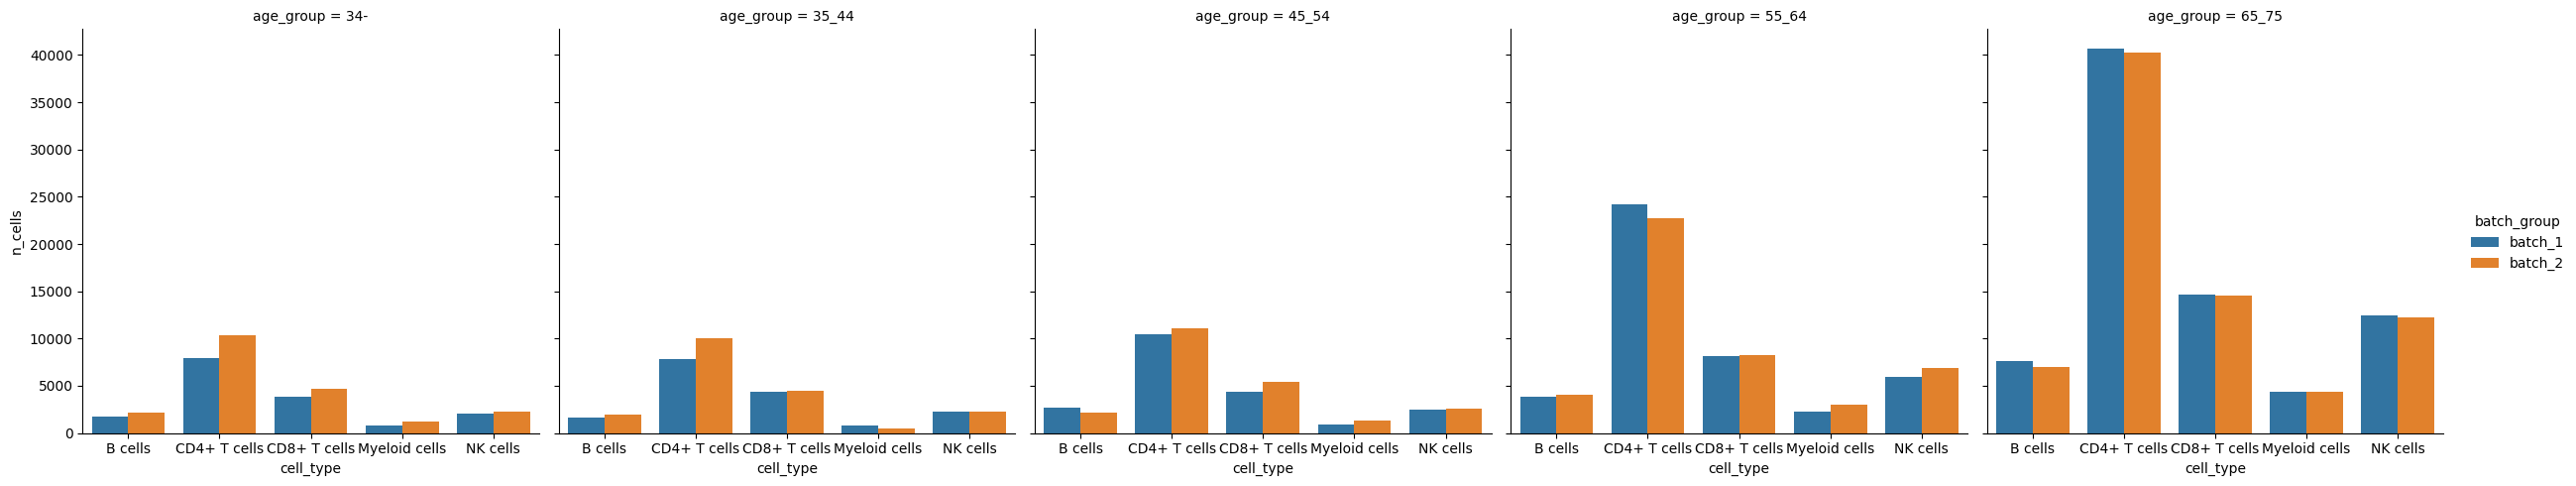

In [24]:
n_cells = adata.obs.groupby(['age_group', 'cell_type', 'batch_group']).size().reset_index(name='n_cells')
sns.catplot(n_cells, x='cell_type', y='n_cells', col='age_group', hue='batch_group', kind='bar')

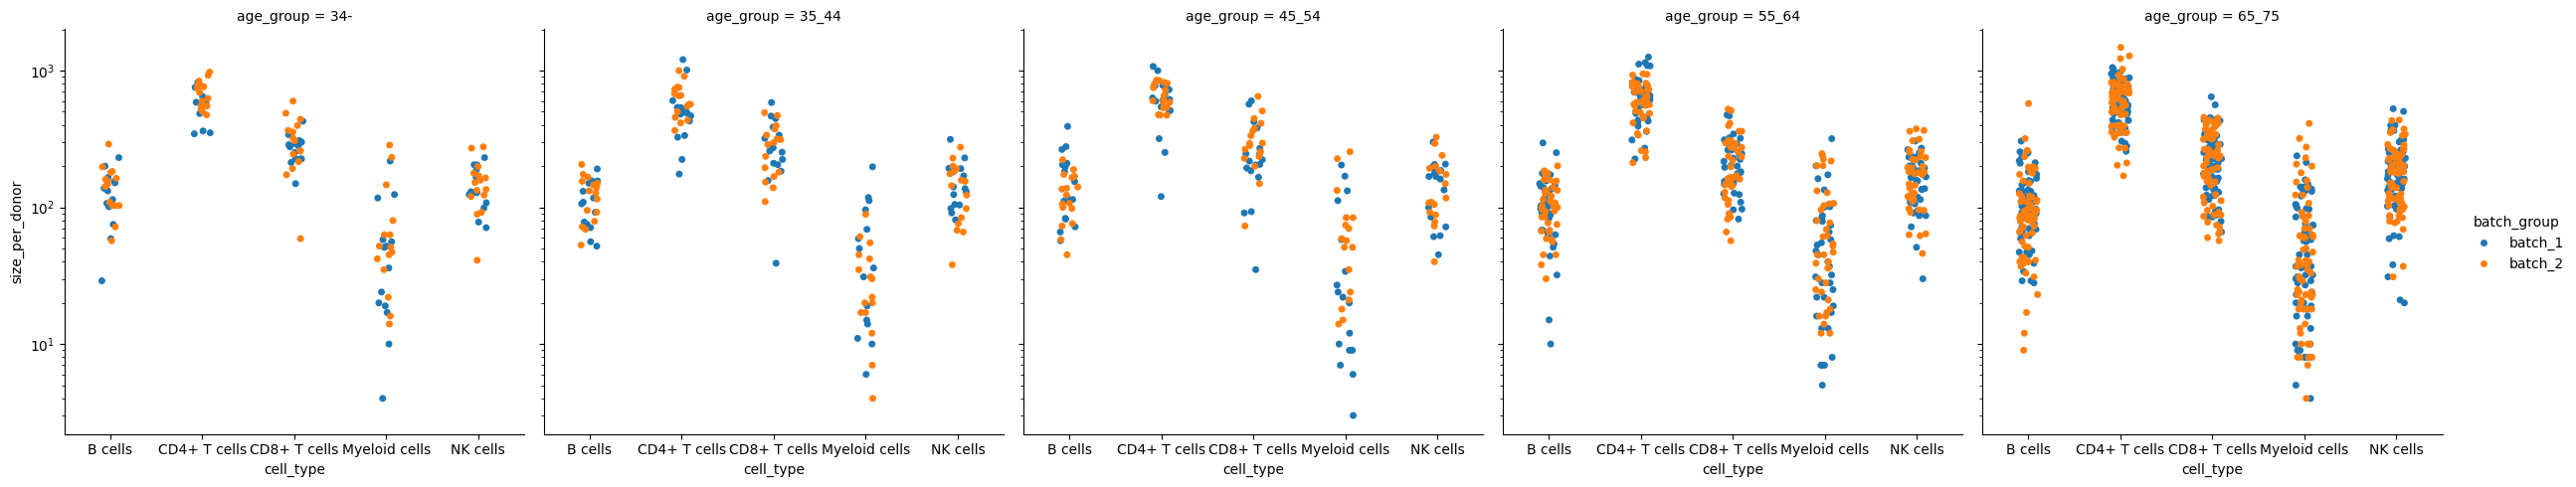

In [25]:
size_per_donor = adata.obs.groupby(['age_group', 'cell_type', 'batch_group','donor_id']).size().reset_index(name='size_per_donor')
g= sns.catplot(size_per_donor, x='cell_type', y='size_per_donor', col='age_group', hue='batch_group', kind='strip')
g.set(yscale="log")

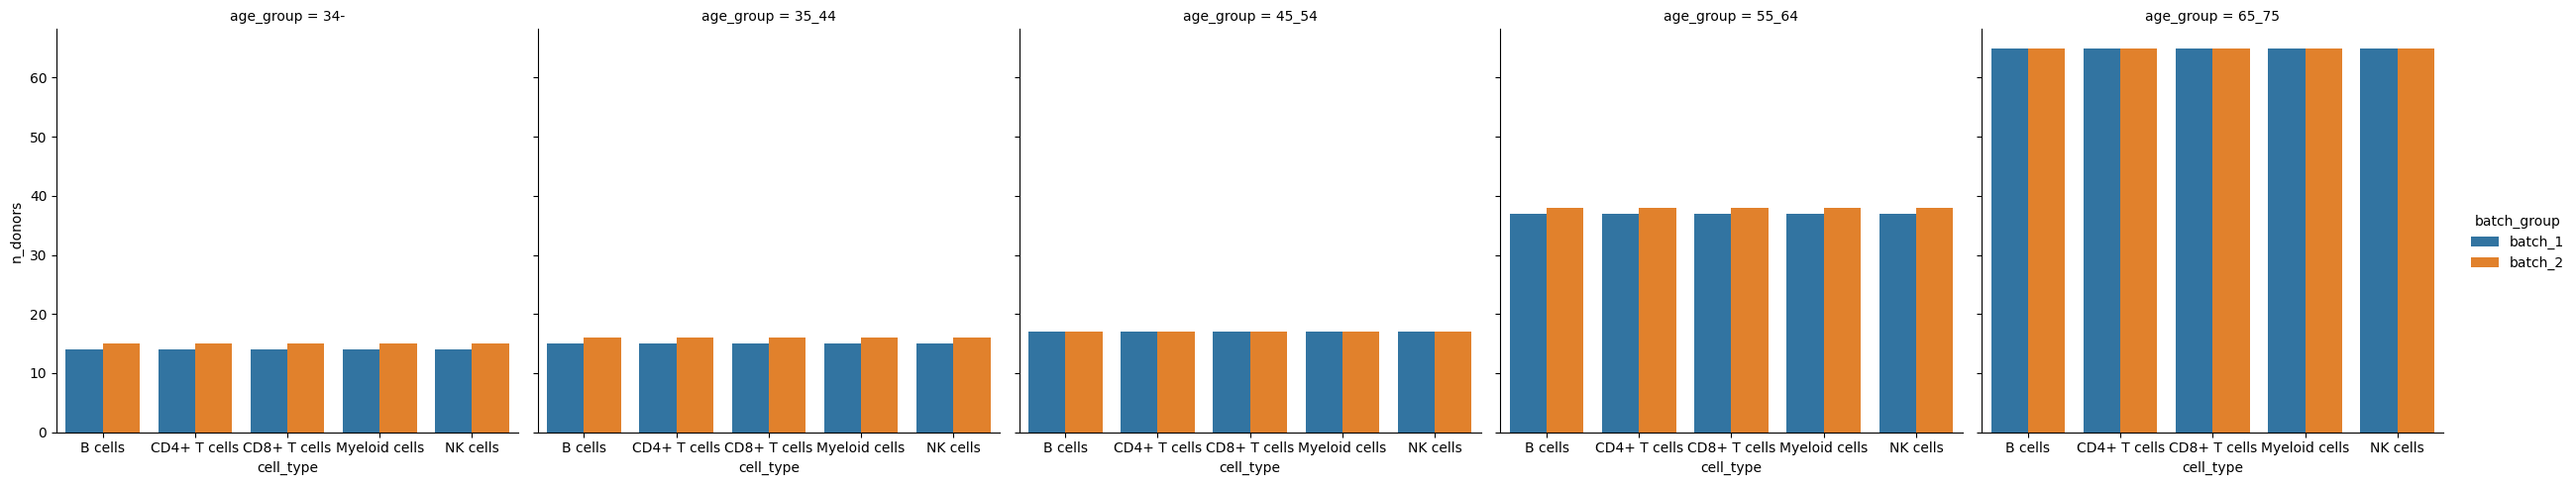

In [26]:
n_donors = adata.obs.groupby(['age_group', 'cell_type', 'batch_group'])['donor_id'].nunique().reset_index(name='n_donors')
sns.catplot(n_donors, x='cell_type', y='n_donors', col='age_group', hue='batch_group', kind='bar')

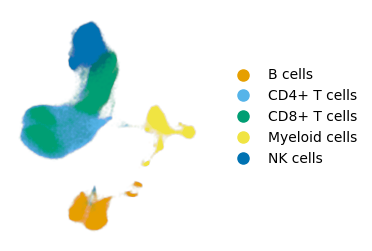

In [27]:
from src.helper import cell_type_palette

def plot_umap(adata, color='', palette=None, ax=None, X_label='X_umap', on_data=False,
              bbox_to_anchor=None, legend=True, legend_title='', **kwrds):
    latent = adata.obsm[X_label]
    var_unique_sorted = sorted(adata.obs[color].unique())
    legend_handles = []
    
    for i_group, group in enumerate(var_unique_sorted):
        mask = adata.obs[color] == group
        sub_data = latent[mask]
        if palette is None:
            c = None 
        else:
            c = palette[group]
        # Plot scatter points
        scatter = ax.scatter(sub_data[:, 0], sub_data[:, 1], label=group, c=c, **kwrds)
        if palette is None:
            solid_color = scatter.get_facecolor()[0]
        else:
            solid_color = c
        # plot legend
        legend_handles.append(plt.Line2D([0], [0], linestyle='none', marker='o', markersize=8, color=solid_color))
        if on_data:
            mean_x = np.mean(sub_data[:, 0])
            mean_y = np.mean(sub_data[:, 1])
            ax.text(mean_x, mean_y, group, fontsize=9, ha='center', va='top', color='black', weight='bold')
    ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticks([])
    ax.set_yticks([])

    if legend and not on_data:
        legend = ax.legend(handles=legend_handles, labels=var_unique_sorted, loc=(1.1,.3), 
                           bbox_to_anchor=bbox_to_anchor, frameon=False, title=legend_title, 
                           title_fontproperties={'weight': 'bold', 'size': 9})
        legend.get_title().set_ha('left')
        legend._legend_box.align = "left" 
    

# Example usage
fig, ax = plt.subplots(1, 1, figsize=(2.5, 3))
plot_umap(adata, color='cell_type', ax=ax, s=1, alpha=0.01, palette=cell_type_palette)  
# plot_umap(adata[adata.obs['batch_group']=='batch_2'], color='batch_group', ax=ax, s=1, alpha=0.3)  
# plot_umap(adata, color='donor_id', ax=ax, s=1, alpha=0.3)  
plt.savefig('output/figs/umap_dataset1.png', dpi=300, bbox_inches='tight')
